Loading synthetic data...


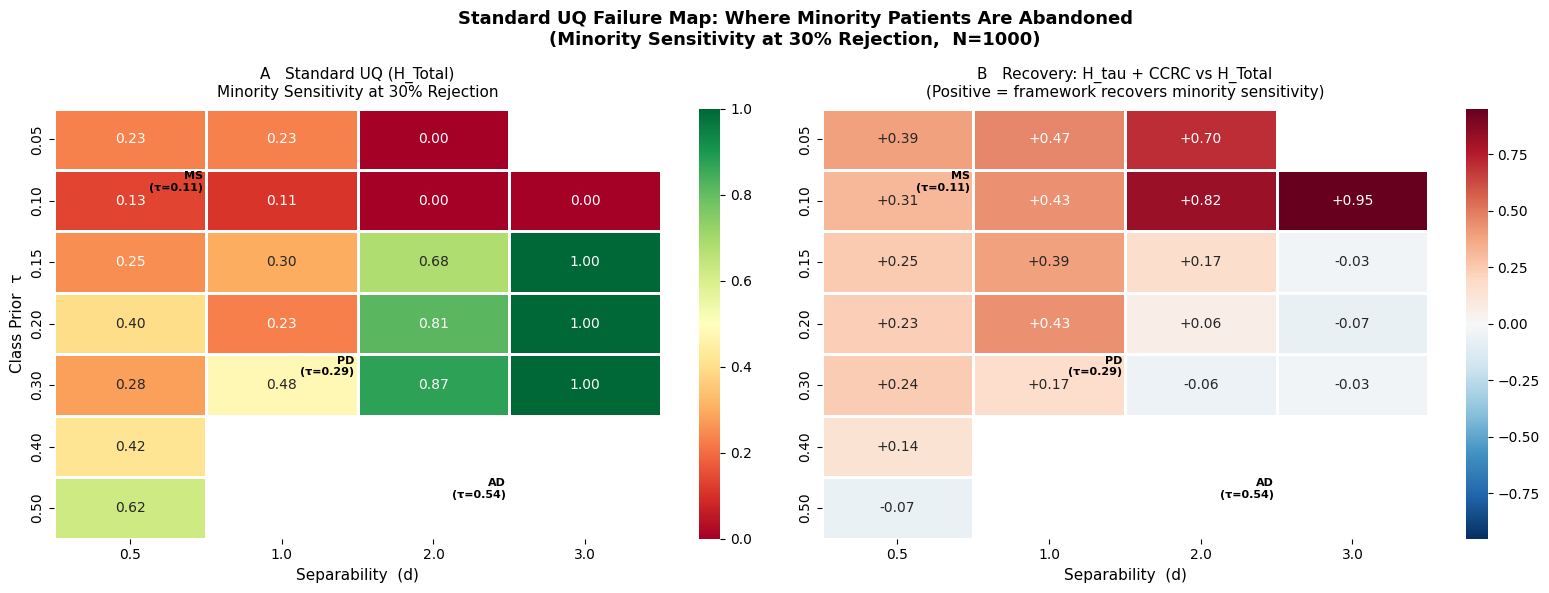

In [3]:
import argparse
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import gaussian_kde

print("Loading synthetic data...")
scalars = pd.read_csv('../data/synthetic_results/scalar_summaries_full.csv')
n=1000
"""
Phase diagram reframed as a failure map.
Two panels: H_Total | Difference (Proposed - Baseline)
Phase boundary prominently marked.
Disease points as primary visual anchors.
"""
df = scalars[scalars['n'] == n].copy()
metric = 'sensitivity_at_30pct'

tau_vals = sorted(df['tau'].unique())
d_vals   = sorted(df['d'].unique())

def make_grid(method):
    return (
        df[df['method'] == method]
        .pivot(index='tau', columns='d', values=metric)
        .reindex(index=tau_vals, columns=d_vals)
        .values
    )

grid_htotal = make_grid('h_total')
grid_ccrc   = make_grid('h_tau_ccrc')
grid_diff   = grid_ccrc - grid_htotal

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Standard UQ Failure Map: Where Minority Patients Are Abandoned\n'
    f'(Minority Sensitivity at 30% Rejection,  N={n})',
    fontsize=13, fontweight='bold'
)

kw = dict(
    xticklabels=[str(d) for d in d_vals],
    yticklabels=[f'{t:.2f}' for t in tau_vals],
    linewidths=0.8, linecolor='white',
)

# Panel A: H_Total failure map
# Custom colormap: red (failure) → yellow → green (safe)
sns.heatmap(
    grid_htotal, ax=axes[0],
    vmin=0, vmax=1,
    cmap='RdYlGn',
    annot=True, fmt='.2f', annot_kws={'size': 10},
    **kw
)
axes[0].set_title('A   Standard UQ (H_Total)\nMinority Sensitivity at 30% Rejection',
                    fontsize=11, pad=8)
axes[0].set_xlabel('Separability  (d)', fontsize=11)
axes[0].set_ylabel('Class Prior  τ', fontsize=11)
"""
# Draw phase boundary: contour where sensitivity < 0.5
# Approximate by shading cells where value < 0.5
for ri, row in enumerate(grid_htotal):
    for ci, val in enumerate(row):
        if not np.isnan(val) and val < 0.5:
            axes[0].add_patch(plt.Rectangle(
                (ci, ri), 1, 1,
                fill=False, edgecolor='#C0392B',
                linewidth=2.5, zorder=5
            ))

# Add "DANGER ZONE" label
axes[0].text(
    0.5, 0.15,
    'DANGER ZONE\n(sensitivity < 0.5)',
    transform=axes[0].transAxes,
    fontsize=9, color='#C0392B', fontweight='bold',
    ha='center', va='bottom',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                edgecolor='#C0392B', alpha=0.9)
)
"""
# Panel B: Difference map — the recovery
vmax_diff = max(0.01, np.nanmax(np.abs(grid_diff)))
im = sns.heatmap(
    grid_diff, ax=axes[1],
    vmin=-vmax_diff, vmax=vmax_diff,
    cmap='RdBu_r', center=0,
    annot=True, fmt='+.2f', annot_kws={'size': 10},
    **kw
)
axes[1].set_title('B   Recovery: H_tau + CCRC vs H_Total\n(Positive = framework recovers minority sensitivity)',
                    fontsize=11, pad=8)
axes[1].set_xlabel('Separability  (d)', fontsize=11)
axes[1].set_ylabel('')

# Disease points — primary visual anchors
disease_tau_d = {
    'MS\n(τ=0.11)': (0.10, 0.5),
    'PD\n(τ=0.29)': (0.30, 1.0),
    'AD\n(τ=0.54)': (0.50, 2.0),
}
for label, (tau_r, d_r) in disease_tau_d.items():
    tau_idx = np.argmin(np.abs(np.array(tau_vals) - tau_r))
    d_idx   = np.argmin(np.abs(np.array(d_vals)   - d_r))

    for ax in axes:

        ax.text(
            d_idx + 0.98, tau_idx + 0.02, label,
            ha='right', va='top',
            fontsize=8, fontweight='bold', color='black',
            zorder=7
        )

plt.tight_layout()
plt.show()
plt.close()


In [8]:
scalars[scalars['tau']==0.20]

,tau,d,n,method,method_label,uses_ccrc,base_signal,sensitivity_at_30pct,specificity_at_30pct,sensitivity_stability,minority_coverage_at_30pct,class_separation,ccaugrc_progressor,ccaugrc_stable,global_augrc
144,0.2,0.5,300,h_total,H_Total (Global),False,h_total,0.294118,0.801136,-1.273959,0.576271,0.367126,0.314852,0.085078,0.128846
145,0.2,0.5,300,margin,Margin (Global),False,margin,0.634146,0.615385,0.227077,0.694915,1.030488,0.164895,0.204479,0.196405
146,0.2,0.5,300,h_tau,H_tau (Global),False,h_tau,0.500000,0.718391,-0.431285,0.610169,0.696000,0.249785,0.121953,0.148161
147,0.2,0.5,300,h_tau_ccrc,H_tau + CCRC,True,h_tau,0.568182,0.584337,-0.072486,0.745763,0.972352,0.211577,0.203099,0.205853
148,0.2,0.5,300,h_total_ccrc,H_Total + CCRC,True,h_total,0.577778,0.587879,-0.026763,0.762712,0.982818,0.202384,0.200946,0.202425
149,0.2,0.5,300,margin_ccrc,Margin + CCRC,True,margin,0.568182,0.584337,-0.072486,0.745763,0.972352,0.211577,0.203099,0.205853
150,0.2,0.5,1000,h_total,H_Total (Global),False,h_total,0.396396,0.789474,-1.335235,0.555000,0.502102,0.273487,0.087938,0.123900
151,0.2,0.5,1000,margin,Margin (Global),False,margin,0.720000,0.613913,0.170828,0.625000,1.172805,0.136475,0.197252,0.184850
152,0.2,0.5,1000,h_tau,H_tau (Global),False,h_tau,0.569106,0.729636,-0.434299,0.615000,0.779986,0.220300,0.114331,0.135200
153,0.2,0.5,1000,h_tau_ccrc,H_tau + CCRC,True,h_tau,0.630435,0.571936,-0.113648,0.690000,1.102282,0.180413,0.207883,0.202825
